# Exploratory Data Analysis of the Data Center Load Dataset

This notebook explores power usage, efficiency, and utilization in an enterprise data center dataset. The goal is to understand:
- how power demand changes over time,
- what drives cooling load and PUE,
- whether temperature or compute utilization are strong predictors,
- and how extreme facility load events behave.

The analysis uses time-series inspection, summary statistics, correlation analysis, seasonal and hourly patterns, and extreme-event comparison.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

path = Path("data") / "Enterprise_DC_Load_Dataset_2024 500 CPU 100GPU System.xlsx"

df = pd.read_excel(path, sheet_name="Full_Dataset", header=1)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df.head()

,Timestamp,Month,Day,Hour,T_amb (°C),u_CPU fleet,u_GPU fleet,P_CPU fleet (kW),Q_CPU fleet (kVAr),P_CPU/server (W),...,Q_lighting (kVAr),P_BMS/sec (kW),Q_BMS/sec (kVAr),P_facility (kW),Q_facility (kVAr),S_facility (kVA),PF_facility,PUE,R_rack composite,ML Split
0,2024-01-01 00:00:00,1,Monday,0,-1.22,0.1959,0.1520,97.213,41.412,194.43,...,7.26,8,4.32,248.428,120.326,276.034,0.9000,1.5494,0.3379,Train
1,2024-01-01 01:00:00,1,Monday,1,3.32,0.2512,0.2169,107.720,45.888,215.44,...,7.26,8,4.32,282.096,137.028,313.616,0.8995,1.5428,0.3862,Train
2,2024-01-01 02:00:00,1,Monday,2,-0.12,0.2562,0.2454,108.676,46.296,217.35,...,7.26,8,4.32,289.313,140.463,321.608,0.8996,1.5302,0.4001,Train
3,2024-01-01 03:00:00,1,Monday,3,1.82,0.5654,0.2885,167.429,71.325,334.86,...,7.26,8,4.32,384.500,185.502,426.909,0.9007,1.5031,0.5357,Train
4,2024-01-01 04:00:00,1,Monday,4,0.62,0.4087,0.6201,137.649,58.638,275.30,...,7.26,8,4.32,428.274,209.387,476.720,0.8984,1.4903,0.6156,Train


In [3]:
df.shape
df.info()
df.isna().sum().sort_values(ascending=False).head(10)

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 53 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Timestamp              8760 non-null   datetime64[us]
 1   Month                  8760 non-null   int64         
 2   Day                    8760 non-null   str           
 3   Hour                   8760 non-null   int64         
 4   T_amb (°C)             8760 non-null   float64       
 5   u_CPU fleet            8760 non-null   float64       
 6   u_GPU fleet            8760 non-null   float64       
 7   P_CPU fleet (kW)       8760 non-null   float64       
 8   Q_CPU fleet (kVAr)     8760 non-null   float64       
 9   P_CPU/server (W)       8760 non-null   float64       
 10  Q_CPU/server (VAr)     8760 non-null   float64       
 11  P_GPU fleet (kW)       8760 non-null   float64       
 12  Q_GPU fleet (kVAr)     8760 non-null   float64       
 13  P_GPU/server (

Timestamp             0
Month                 0
Day                   0
Hour                  0
T_amb (°C)            0
u_CPU fleet           0
u_GPU fleet           0
P_CPU fleet (kW)      0
Q_CPU fleet (kVAr)    0
P_CPU/server (W)      0
dtype: int64

In [4]:
key_cols = [
    "P_IT total (kW)",
    "P_facility (kW)",
    "P_cooling (kW)",
    "P_loss total (kW)",
    "PUE",
    "T_amb (°C)",
    "u_CPU fleet",
    "u_GPU fleet",
]

df[key_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
P_IT total (kW),8760.0,265.100240,85.012748,132.7500,188.128000,258.42200,334.08125,466.2000
P_facility (kW),8760.0,409.142861,125.656788,208.9010,296.527500,398.11950,509.11150,723.3260
P_cooling (kW),8760.0,77.324111,28.126861,31.2580,54.040000,73.05650,96.14650,161.7640
P_loss total (kW),8760.0,43.718512,14.019716,21.8920,31.024500,42.61700,55.09425,76.8830
PUE,8760.0,1.551901,0.046730,1.4515,1.515200,1.55110,1.58270,1.6985
T_amb (°C),8760.0,15.009111,10.916383,-5.0000,4.710000,15.06000,25.41000,38.2400
u_CPU fleet,8760.0,0.487058,0.246573,0.1500,0.258975,0.46865,0.68950,0.9800
u_GPU fleet,8760.0,0.419238,0.223135,0.0500,0.233000,0.40555,0.59110,1.0000


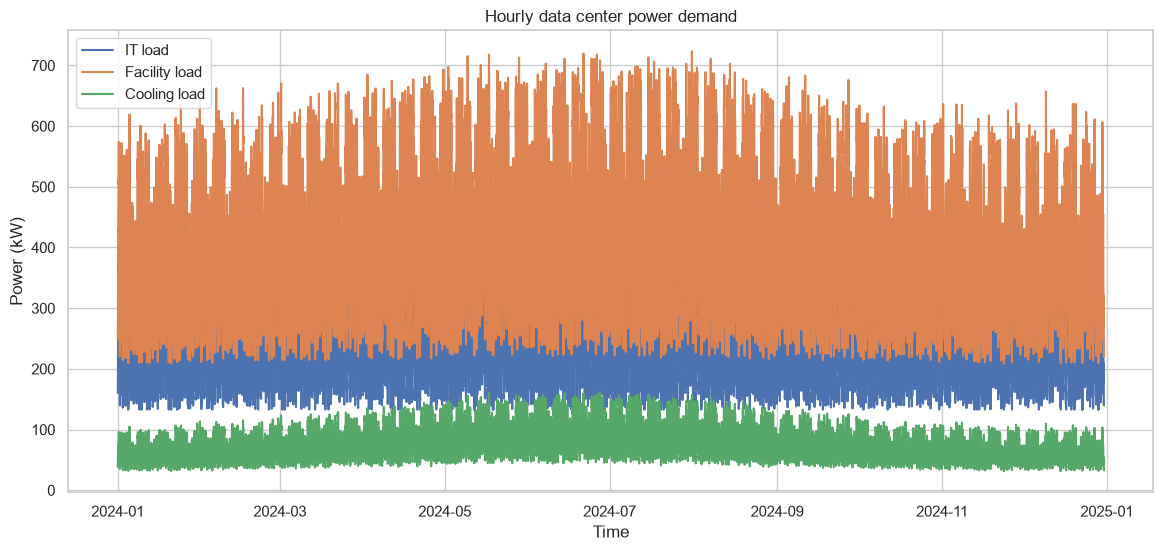

In [5]:
plt.figure(figsize=(14, 6))

plt.plot(df["Timestamp"], df["P_IT total (kW)"], label="IT load")
plt.plot(df["Timestamp"], df["P_facility (kW)"], label="Facility load")
plt.plot(df["Timestamp"], df["P_cooling (kW)"], label="Cooling load")

plt.title("Hourly data center power demand")
plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.legend()
plt.show()

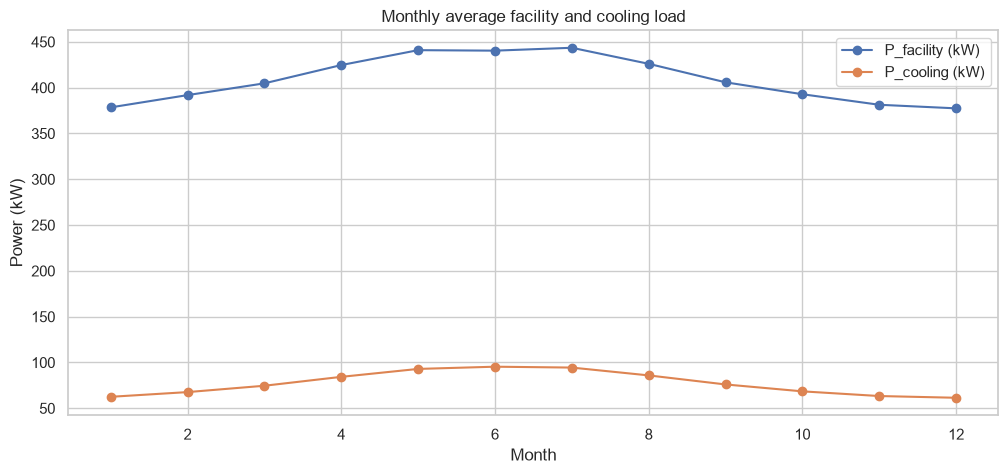

In [6]:
monthly = df.groupby("Month")[[
    "P_IT total (kW)",
    "P_facility (kW)",
    "P_cooling (kW)",
    "PUE",
    "T_amb (°C)"
]].mean()

monthly

monthly[["P_facility (kW)", "P_cooling (kW)"]].plot(marker="o", figsize=(12, 5))
plt.title("Monthly average facility and cooling load")
plt.xlabel("Month")
plt.ylabel("Power (kW)")
plt.show()

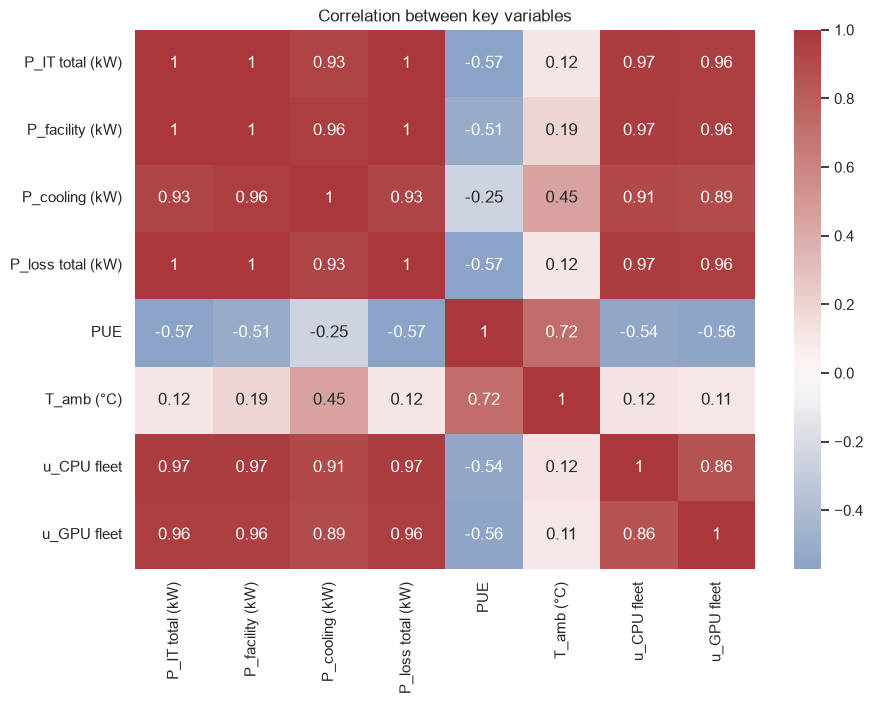

In [7]:
corr = df[key_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="vlag", center=0)
plt.title("Correlation between key variables")
plt.show()

In [8]:
df.nlargest(10, "P_facility (kW)")[
    ["Timestamp", "P_facility (kW)", "P_IT total (kW)", "P_cooling (kW)", "PUE", "T_amb (°C)", "u_CPU fleet", "u_GPU fleet"]
]

,Timestamp,P_facility (kW),P_IT total (kW),P_cooling (kW),PUE,T_amb (°C),u_CPU fleet,u_GPU fleet
5099,2024-07-31 11:00:00,723.326,466.200,157.244,1.5515,28.38,0.9800,1.0000
4136,2024-06-21 08:00:00,719.322,460.828,159.497,1.5609,30.27,0.9800,0.9710
4255,2024-06-26 07:00:00,718.046,461.253,157.727,1.5567,29.39,0.9619,0.9918
3297,2024-05-17 09:00:00,717.836,458.514,160.708,1.5656,31.17,0.9499,0.9894
3107,2024-05-09 11:00:00,715.505,460.686,155.847,1.5531,28.60,0.9800,0.9702
4712,2024-07-15 08:00:00,713.348,458.153,156.640,1.5570,29.38,0.9376,1.0000
3564,2024-05-28 12:00:00,713.075,458.781,155.635,1.5543,28.81,0.9648,0.9755
3968,2024-06-14 08:00:00,711.098,456.257,156.598,1.5585,29.66,0.9486,0.9785
5266,2024-08-07 10:00:00,711.097,458.861,153.564,1.5497,27.80,0.9800,0.9603
4208,2024-06-24 08:00:00,711.003,458.508,153.881,1.5507,28.01,0.9395,1.0000


In [9]:
df["Month"] = df["Timestamp"].dt.month
df["DayOfWeek"] = df["Timestamp"].dt.day_name()
df["Hour"] = df["Timestamp"].dt.hour
df["IsWeekend"] = df["DayOfWeek"].isin(["Saturday", "Sunday"])

In [10]:
print("Duplicate rows:", df.duplicated().sum())

invalid_power = df[
    (df["P_IT total (kW)"] < 0)
    | (df["P_facility (kW)"] < 0)
    | (df["P_cooling (kW)"] < 0)
]
print("Invalid power rows:", invalid_power.shape[0])
print(invalid_power.head())

invalid_util = df[
    (df["u_CPU fleet"] < 0)
    | (df["u_CPU fleet"] > 100)
    | (df["u_GPU fleet"] < 0)
    | (df["u_GPU fleet"] > 100)
]
print("Invalid utilization rows:", invalid_util.shape[0])
print(invalid_util.head())

Duplicate rows: 0
Invalid power rows: 0
Empty DataFrame
Columns: [Timestamp, Month, Day, Hour, T_amb (°C), u_CPU fleet, u_GPU fleet, P_CPU fleet (kW), Q_CPU fleet (kVAr), P_CPU/server (W), Q_CPU/server (VAr), P_GPU fleet (kW), Q_GPU fleet (kVAr), P_GPU/server (W), Q_GPU/server (VAr), P_IT total (kW), Q_IT total (kVAr), PF_IT, P_rack CPU avg (kW), Q_rack CPU avg (kVAr), R_rack CPU, P_rack GPU avg (kW), Q_rack GPU avg (kVAr), R_rack GPU, P_PDU avg (kW), Q_PDU avg (kVAr), R_PDU, P_PSU loss (kW), Q_PSU loss (kVAr), P_PDU loss (kW), Q_PDU loss (kVAr), P_UPS loss (kW), Q_UPS loss (kVAr), P_XFMR loss (kW), Q_XFMR loss (kVAr), P_cable loss (kW), Q_cable loss (kVAr), P_loss total (kW), Q_loss total (kVAr), COP, P_cooling (kW), Q_cooling (kVAr), P_lighting (kW), Q_lighting (kVAr), P_BMS/sec (kW), Q_BMS/sec (kVAr), P_facility (kW), Q_facility (kVAr), S_facility (kVA), PF_facility, PUE, R_rack composite, ML Split, DayOfWeek, IsWeekend]
Index: []

[0 rows x 55 columns]
Invalid utilization rows: 0
E

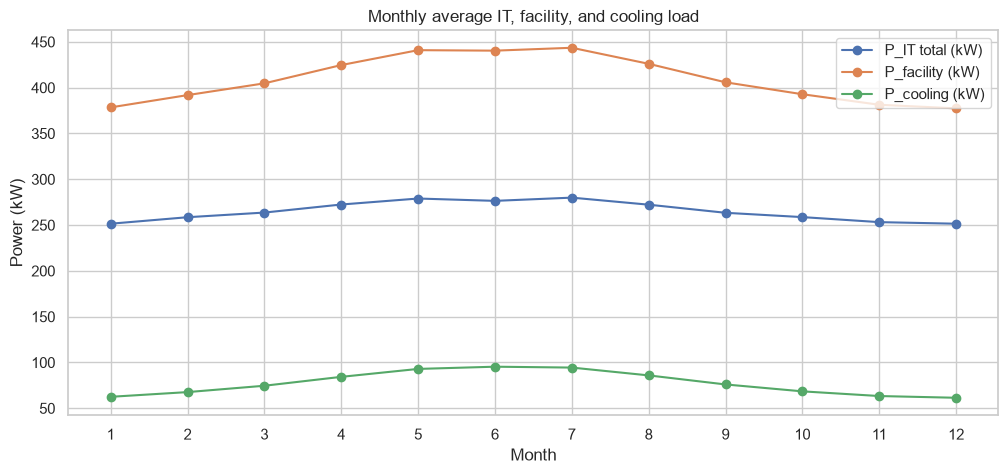

In [11]:
monthly = df.groupby("Month")[
    ["P_IT total (kW)", "P_facility (kW)", "P_cooling (kW)", "PUE", "T_amb (°C)"]
].mean()

monthly[["P_IT total (kW)", "P_facility (kW)", "P_cooling (kW)"]].plot(
    marker="o", figsize=(12, 5)
)
plt.title("Monthly average IT, facility, and cooling load")
plt.xlabel("Month")
plt.ylabel("Power (kW)")
plt.xticks(range(1, 13))
plt.show()

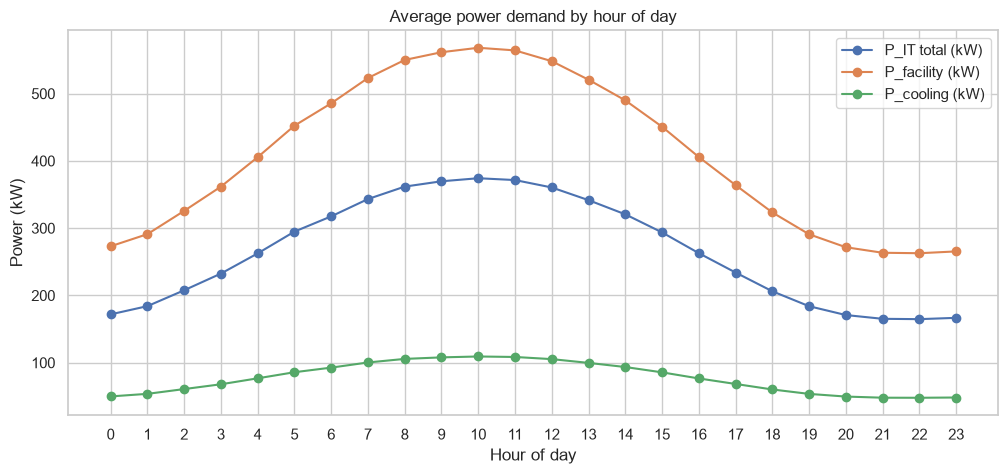

In [12]:
hourly = df.groupby("Hour")[
    ["P_IT total (kW)", "P_facility (kW)", "P_cooling (kW)"]
].mean()

hourly.plot(marker="o", figsize=(12, 5))
plt.title("Average power demand by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Power (kW)")
plt.xticks(range(0, 24))
plt.show()

C:\Users\boulanger\AppData\Local\Temp\ipykernel_31608\580346788.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


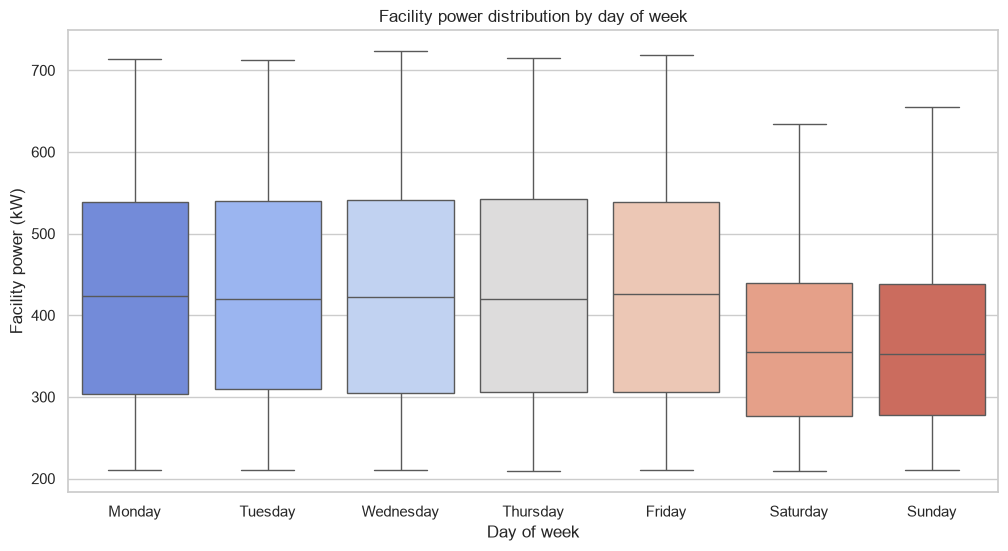

In [13]:
plt.figure(figsize=(12, 6))
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.boxplot(
    x="DayOfWeek",
    y="P_facility (kW)",
    data=df,
    order=order,
    palette="coolwarm"
)
plt.title("Facility power distribution by day of week")
plt.xlabel("Day of week")
plt.ylabel("Facility power (kW)")
plt.show()

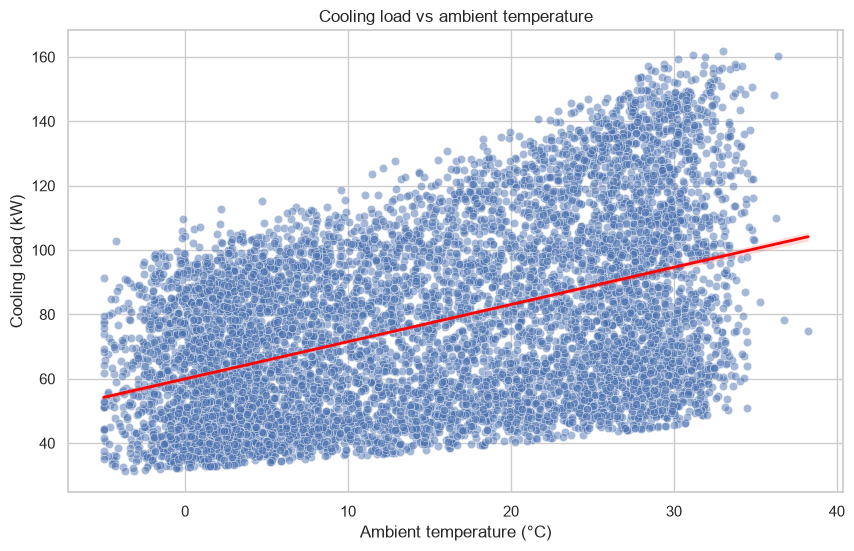

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="T_amb (°C)",
    y="P_cooling (kW)",
    data=df,
    alpha=0.5
)
sns.regplot(
    x="T_amb (°C)",
    y="P_cooling (kW)",
    data=df,
    scatter=False,
    color="red",
    line_kws={"linewidth": 2}
)
plt.title("Cooling load vs ambient temperature")
plt.xlabel("Ambient temperature (°C)")
plt.ylabel("Cooling load (kW)")
plt.show()

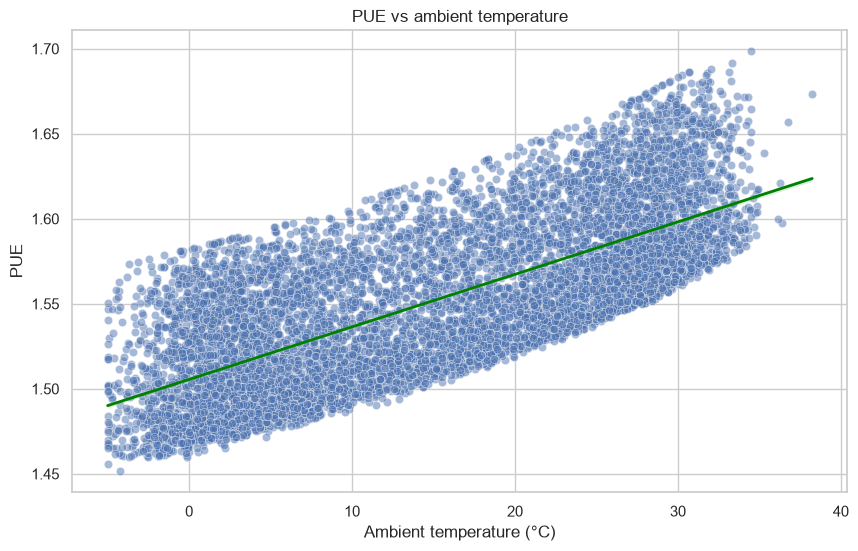

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="T_amb (°C)",
    y="PUE",
    data=df,
    alpha=0.5
)
sns.regplot(
    x="T_amb (°C)",
    y="PUE",
    data=df,
    scatter=False,
    color="green",
    line_kws={"linewidth": 2}
)
plt.title("PUE vs ambient temperature")
plt.xlabel("Ambient temperature (°C)")
plt.ylabel("PUE")
plt.show()

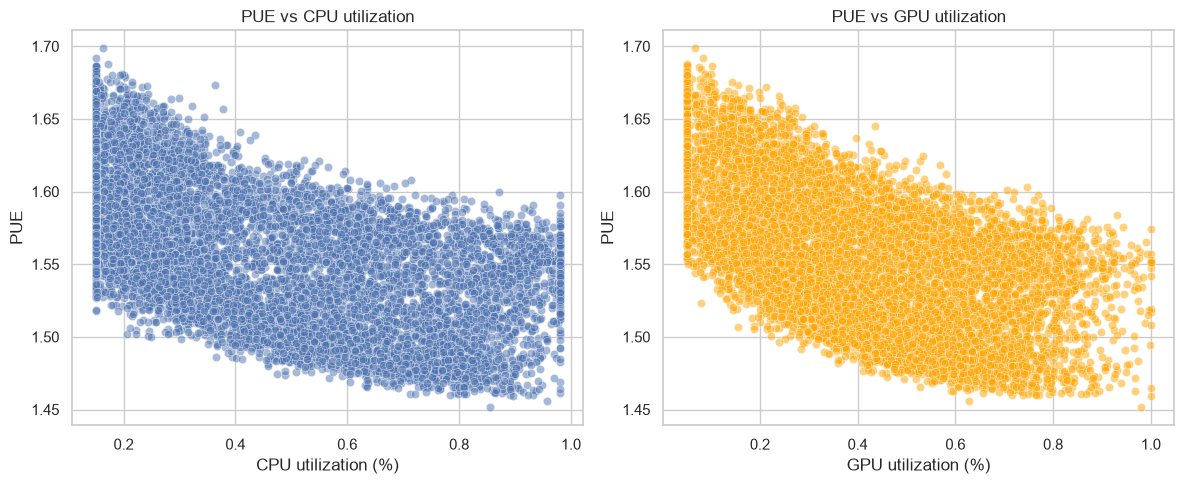

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x="u_CPU fleet",
    y="PUE",
    data=df,
    alpha=0.5
)
plt.title("PUE vs CPU utilization")
plt.xlabel("CPU utilization (%)")
plt.ylabel("PUE")

plt.subplot(1, 2, 2)
sns.scatterplot(
    x="u_GPU fleet",
    y="PUE",
    data=df,
    alpha=0.5,
    color="orange"
)
plt.title("PUE vs GPU utilization")
plt.xlabel("GPU utilization (%)")
plt.ylabel("PUE")

plt.tight_layout()
plt.show()

In [17]:
df["cooling_share"] = df["P_cooling (kW)"] / df["P_facility (kW)"]
df["loss_share"] = df["P_loss total (kW)"] / df["P_facility (kW)"]
df["it_share"] = df["P_IT total (kW)"] / df["P_facility (kW)"]

df[["cooling_share", "loss_share", "it_share"]].describe().T

,count,mean,std,min,25%,50%,75%,max
cooling_share,8760.0,0.186720,0.019910,0.149631,0.168511,0.184705,0.204445,0.236700
loss_share,8760.0,0.106361,0.003181,0.097095,0.104197,0.106323,0.108841,0.113616
it_share,8760.0,0.644952,0.019289,0.588754,0.631825,0.644719,0.659985,0.688943


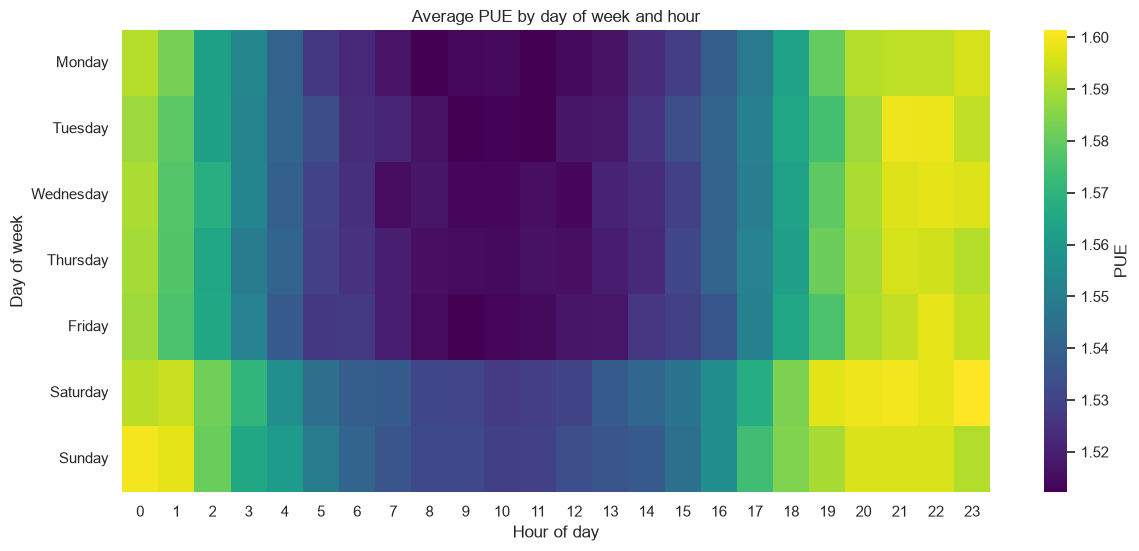

In [18]:
pue_pivot = df.pivot_table(
    index="DayOfWeek",
    columns="Hour",
    values="PUE",
    aggfunc="mean"
).reindex(order)

plt.figure(figsize=(14, 6))
sns.heatmap(
    pue_pivot,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "PUE"}
)
plt.title("Average PUE by day of week and hour")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.show()

In [19]:
top_facility = df.nlargest(10, "P_facility (kW)")[[
    "Timestamp",
    "P_facility (kW)",
    "P_IT total (kW)",
    "P_cooling (kW)",
    "PUE",
    "T_amb (°C)",
    "u_CPU fleet",
    "u_GPU fleet"
]]
print("Top 10 facility power events")
print(top_facility)

high_load = df["P_facility (kW)"] > df["P_facility (kW)"].quantile(0.90)
summary = df.groupby(high_load)[
    ["PUE", "T_amb (°C)", "u_CPU fleet", "u_GPU fleet", "cooling_share"]
].mean()
summary.index = ["Normal / Lower load", "High load"]
print(summary)

Top 10 facility power events
               Timestamp  P_facility (kW)  P_IT total (kW)  P_cooling (kW)  \
5099 2024-07-31 11:00:00          723.326          466.200         157.244   
4136 2024-06-21 08:00:00          719.322          460.828         159.497   
4255 2024-06-26 07:00:00          718.046          461.253         157.727   
3297 2024-05-17 09:00:00          717.836          458.514         160.708   
3107 2024-05-09 11:00:00          715.505          460.686         155.847   
4712 2024-07-15 08:00:00          713.348          458.153         156.640   
3564 2024-05-28 12:00:00          713.075          458.781         155.635   
3968 2024-06-14 08:00:00          711.098          456.257         156.598   
5266 2024-08-07 10:00:00          711.097          458.861         153.564   
4208 2024-06-24 08:00:00          711.003          458.508         153.881   

         PUE  T_amb (°C)  u_CPU fleet  u_GPU fleet  
5099  1.5515       28.38       0.9800       1.0000  
4136  

## Conclusion

The dataset shows that the data center’s power profile is driven by both IT demand and ambient temperature. Cooling power is strongly temperature-dependent, and PUE tends to worsen as outside temperature rises. Daily and weekly patterns are visible through the hourly and weekday analyses, although the data center appears to run fairly consistently across the day. The highest facility power events coincide with hot weather and increased cooling demand, which suggests that improving cooling efficiency in warm periods would have the biggest impact on overall energy performance.

Key takeaways:
- Cooling is a major contributor to facility power and varies seasonally.
- Temperature has a stronger influence on PUE than CPU/GPU utilization.
- Extreme load periods are characterized by high ambient temperature and high cooling share.
- Understanding these patterns can help target efficiency improvements in thermal management and load balancing.